# HYBRID FOD

This Notebook shows how to interact with the `cmc_hybrid` package through Python commands.


In [2]:
# Usul suspects
import numpy as np
import matplotlib.pyplot as plt


In [3]:
# Imports from cmc_hybrid
from cmc_hybrid import utils, fod
from cmc_hybrid import coordinate_mapping as cm


In [4]:
# Load bedpostx sample orientations and volume fractions
from glob import glob
from fsl.data.image import Image
import os
bpx = '/Users/saad/data/CMC/Moe_DTI/diffusion.bedpostX'
ths = [Image(x).data for x in sorted(glob(os.path.join(bpx,'merged_th?samples.nii.gz')))]
phs = [Image(x).data for x in sorted(glob(os.path.join(bpx,'merged_ph?samples.nii.gz')))]
fs  = [Image(x).data for x in sorted(glob(os.path.join(bpx,'merged_f?samples.nii.gz')))]

# This is a volume used for reference in coordinate mappings dMRI<-->PSOCT
volume = Image(bpx+'/nodif_brain_mask')

## Transform dMRI BPX samples into FOD and visualise

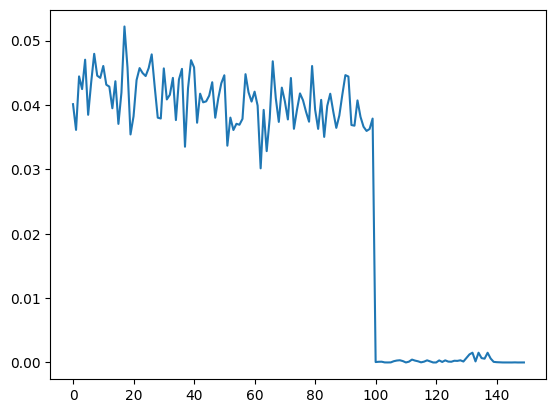

In [8]:
f_samples  = np.array([f[x,y,z,:]  for f in fs]).flatten()
plt.plot(f_samples)

In [10]:
# Look at a single voxel
vox_diff   = [66,83,33]
x,y,z      = np.array(vox_diff).astype(int)
th_samples = np.array([th[x,y,z,:] for th in ths]).flatten()
ph_samples = np.array([ph[x,y,z,:] for ph in phs]).flatten()
f_samples  = np.array([f[x,y,z,:]  for f in fs]).flatten()

# threshold fractions
f_thr      = 0.001
f_samples[f_samples<f_thr] = 0.

xyz_samples = utils.pol2cart(th_samples, ph_samples)

coeff_dmri, skde  = fod.fit_sh_fod(xyz_samples, max_order=12, 
                                   symmetric=True, weights=f_samples, 
                                   normalise=True, output_kde=True)

fig = fod.plot_odf_glyph(coeff_dmri, glyph=True, samples=xyz_samples)
fig.update_traces(marker=dict(color=f_samples), selector=dict(type="scatter3d"))
fig.show()



In [ ]:
# PSOCT slides
from fsl.data.image import Image
slide_files = ['/Users/saad/data/CMC/PSOCT/Moe/Orientation/Slice_110_EnAO_header.nii.gz',
               '/Users/saad/data/CMC/PSOCT/Moe/Orientation/Slice_111_EnAO_header.nii.gz',]
slides = [Image(sl) for sl in slide_files]

In [ ]:

# Look at PSOCT FOD (2D)
pixgrid, voxgrid, theta = cm.vox_to_pix(vox_diff, slides, volume)
theta = utils.fudge_psoct_orientation(theta, angle=22)
xform = cm.slide_to_volume(slides[0], volume)
vecs  = cm.angle_to_vector(theta, xform=xform)

coeff_psoct = fod.fit_sh_fod(vecs, max_order=12, symmetric=True, normalise=True)
fig = fod.plot_odf_glyph(coeff_psoct, glyph=True, samples=vecs, notebook=True)
fig.show()



In [ ]:
# Look at PSOCT samples with dMRI glyph
fig = fod.plot_odf_glyph(coeff_dmri, glyph=True, samples=vecs)
fig.show()




In [ ]:
h_vecs     = fod.hybrid_vecs(th_samples, ph_samples, f_samples, vecs, weighted=True, deterministic=True)
res, skde  = fod.fit_sh_fod(h_vecs, max_order=8, symmetric=True,  output_kde=True, normalise=True)

import plotly.graph_objects as go

fig = fod.plot_odf_glyph(coeff_dmri, glyph=True, samples=np.concatenate([h_vecs, -h_vecs], axis=0), notebook=True)
fig.show()

fig = fod.plot_odf_glyph(coeff_dmri, glyph=True, samples=np.concatenate([h_vecs, -h_vecs], axis=0), notebook=True)
fig.show()

